In [1]:
import os

os.chdir('..')

# Lets PyTorch's allocator back non-contiguous virtual memory segments,
# preventing fragmentation OOM during the refine step.
os.environ.setdefault("TORCHINDUCTOR_FX_GRAPH_CACHE", "1")
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

'expandable_segments:True'

In [2]:
import gc

import drjit as dr
import mitsuba as mi

mi.set_variant('cuda_ad_latent16')

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.benchmark as bench

from config import load_config
from figures.common import fonts
from latents.mi_vae import MiVae
from networks import NetworkManager
from renderers import RendererManager
from testing.dr_timer import DrTimer
from utils.img_utils import compute_image_metrics
from utils.plugin_utils import register_plugins

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


In [3]:
# ── Fixed configuration: 128×128 latent → 1024×1024 RGB ──────────────────────
cff = 'configs/runs/ablation/Lamp-1024-Best.yaml'
cfg = load_config(cff)

device     = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype      = cfg['dtype']
torch_dtype = torch.float16 if dtype == 'half' else torch.float32

mi_vae = MiVae(model_name=cfg['model_id'], dtype=torch_dtype, device=device)
register_plugins(cfg)

RGB_RES    = 1024
rgb_ch     = 3
latent_ch  = mi_vae.latent_channels()
latent_res = mi_vae.latent_resolution(RGB_RES)  # 128

print(f'RGB {RGB_RES}×{RGB_RES}, Latent {latent_res}×{latent_res}, ch: {latent_ch}')

renderers = RendererManager(
    cfg, rgb_res=RGB_RES, rgb_ch=rgb_ch, latent_res=latent_res, latent_ch=latent_ch
)
aov_ch = (
    renderers.aov.render(renderers.rgb.scene, renderers.rgb.params).shape[1]
    if cfg['use_aovs'] else 0
)
nets = NetworkManager(cfg, device, latent_ch, aov_ch)
print(f'AOV channels: {aov_ch}')

# ── Threshold configuration ───────────────────────────────────────────────────
A1_THRESHOLDS = [0.1, 0.05, 0.015]   # RGB-space MSE thresholds (Analysis 1)
A2_THRESHOLDS = [0.5, 0.4, 0.3]       # Latent-space MSE thresholds (Analysis 2)
TIME_BUDGETS  = [150, 300, 500, 1000]  # ms — time budgets (Analysis 3)
print(f'A1 thresholds: {A1_THRESHOLDS}')
print(f'A2 thresholds: {A2_THRESHOLDS}')
print(f'A3 budgets:    {TIME_BUDGETS} ms')

/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


RGB 1024×1024, Latent 128×128, ch: 16
Need 3 custom emitters.
Need 18 custom BSDFs.
Need 13 SPDs for this scene.
AOV channels: 4
A1 thresholds: [0.1, 0.05, 0.015]
A2 thresholds: [0.5, 0.4, 0.3]
A3 budgets:    [150, 300, 500, 1000] ms


In [4]:
# ── Load checkpoints + compile fp16 decoder AND encoder ──────────────────────
from training.train_manager import TrainingManager

torch._dynamo.reset()

SCENE_CKPT   = Path('outputs/Lamp-1024-Best/scene.pt')
REFINER_CKPT = Path('outputs/Lamp-1024-Best/refiner.pt')

renderers.load_scene_checkpoint(SCENE_CKPT)
# Populate scene_opt_params from loaded latent params so get_scaled_opt_params()
# can apply sigmoid to reflectance terms during rendering.
renderers.set_optimizable_parameters(TrainingManager.SCENE_OPTIMIZATION_TARGETS)

nets.load_checkpoint(REFINER_CKPT)
nets.eval()

mi_vae.vae = mi_vae.vae.half()
mi_vae.vae.disable_tiling()
mi_vae.vae = mi_vae.vae.to(memory_format=torch.channels_last)

# ── Compiled decoder ──────────────────────────────────────────────────────────
_vae_decode_inner = mi_vae.vae.decode

@torch.compile(dynamic=False, fullgraph=True, mode='max-autotune')
def _compiled_decode_fn(z):
    return _vae_decode_inner(z).sample

def _efficient_decode(latents):
    latents = latents / mi_vae.scaling_factor
    if mi_vae.shift_factor is not None:
        latents = latents + mi_vae.shift_factor
    latents = latents.to(dtype=mi_vae.vae.dtype, device=mi_vae.vae.device)
    image = _compiled_decode_fn(latents)
    return mi_vae.image_processor.postprocess(image, output_type='pt')

mi_vae.decode = _efficient_decode

# ── Compiled encoder ──────────────────────────────────────────────────────────
from diffusers.models.autoencoders.vae import DiagonalGaussianDistribution

_vae_enc_trunk   = mi_vae.vae.encoder
_vae_quant_conv  = getattr(mi_vae.vae, 'quant_conv', None)

if _vae_quant_conv is not None:
    @torch.compile(dynamic=False, mode='max-autotune')
    def _compiled_enc_fn(x):
        return _vae_quant_conv(_vae_enc_trunk(x))
else:
    @torch.compile(dynamic=False, mode='max-autotune')
    def _compiled_enc_fn(x):
        return _vae_enc_trunk(x)

def _efficient_encode(image, return_parameters=False):
    image = image.to(dtype=mi_vae.vae.dtype, device=mi_vae.vae.device)
    image = mi_vae.image_processor.preprocess(image).to(device=mi_vae.vae.device)
    moments = _compiled_enc_fn(image)
    mi_vae._set_latent_distribution(DiagonalGaussianDistribution(moments))
    if return_parameters:
        out = torch.cat((mi_vae.latent_dist.mean, mi_vae.latent_dist.logvar), dim=1)
    else:
        out = mi_vae.latent_dist.sample()
        if mi_vae.shift_factor is not None:
            out = out - mi_vae.shift_factor
        out = out * mi_vae.scaling_factor
    return out

mi_vae.encode = _efficient_encode
print('Checkpoints loaded. scene_opt_params populated. Compiled fp16 decoder + encoder ready.')

Checkpoints loaded. scene_opt_params populated. Compiled fp16 decoder + encoder ready.


In [5]:
# ── Keyframe selection ─────────────────────────────────────────────────────────
# Set KEYFRAME_T in [0.0, 1.0]:  0.0 = trained view, 1.0 = camera_max_x extreme.
# Config: camera_min_x=0, camera_max_x=-60  → at T=0.5 the camera is at -30° azimuth.
KEYFRAME_T = 0.5

_cam_min_az = cfg.get('camera_min_x', 0.0) or 0.0
_cam_max_az = cfg.get('camera_max_x', 0.0) or 0.0
_cam_min_el = cfg.get('camera_min_y', 0.0) or 0.0
_cam_max_el = cfg.get('camera_max_y', 0.0) or 0.0

KEYFRAME_AZ = _cam_min_az + KEYFRAME_T * (_cam_max_az - _cam_min_az)
KEYFRAME_EL = _cam_min_el + KEYFRAME_T * (_cam_max_el - _cam_min_el)

# Move all sensors (RGB, Latent, AOV) to the keyframe view.
# This must happen before the reference render and AOV precomputation cells.
renderers.rotate_sensors(KEYFRAME_AZ, KEYFRAME_EL)
print(f'Keyframe: T={KEYFRAME_T}  az={KEYFRAME_AZ:.1f}°  el={KEYFRAME_EL:.1f}°')

Keyframe: T=0.5  az=-30.0°  el=0.0°


In [6]:
# ── Render converged reference; pre-render AOVs ───────────────────────────────
REF_SPP = 4095   # max for 1024×1024: 4095 × 1024² < 2^32 (drjit uint32 limit)

mi_vae.vae.to('cpu')
torch.cuda.empty_cache()

renderers.rgb.set_spp(REF_SPP)
with dr.suspend_grad():
    ref_gpu = renderers.rgb.render(seed=0, denoiser=False)
    ref_rgb = ref_gpu.float().cpu()
    del ref_gpu
torch.cuda.empty_cache()
print(f'Reference ({REF_SPP} SPP): {ref_rgb.shape}')

with dr.suspend_grad():
    aovs_gpu = renderers.aov.render(renderers.rgb.scene, renderers.latent.params, seed=0)
print(f'AOVs: {aovs_gpu.shape}')

Reference (4095 SPP): torch.Size([1, 3, 1024, 1024])
AOVs: torch.Size([1, 4, 128, 128])


In [7]:
# ── Encode reference; prep GT latent for latent-space analyses ────────────────
mi_vae.vae.to(device)
torch.cuda.empty_cache()

# Warmup: triggers torch.compile + CUDA graph recording for the fixed latent shape.
_warmup_z = torch.zeros(1, latent_ch, latent_res, latent_res, device=device, dtype=torch.float16)
_ = mi_vae.decode(_warmup_z)
_ = mi_vae.decode(_warmup_z)
del _warmup_z
torch.cuda.empty_cache()
print('Decoder compiled.')

@torch.no_grad()
def encode_mean(img_cpu: torch.Tensor) -> torch.Tensor:
    """Deterministic encode: return the scaled encoder mean (no sampling)."""
    img      = img_cpu.to(device=device, dtype=torch_dtype)
    params   = mi_vae.encode(img, return_parameters=True)
    raw_mean = params[:, :latent_ch]
    return mi_vae.scale_mean(raw_mean).float().cpu()

gt_latent_cpu = encode_mean(ref_rgb)
gt_latent_gpu = gt_latent_cpu.to(device)
print(f'GT latent: {gt_latent_cpu.shape}')

mi_vae.vae.to('cpu')
torch.cuda.empty_cache()

Decoder compiled.
GT latent: torch.Size([1, 16, 128, 128])


In [8]:
# # ── Sanity check: confirm scene renders correctly before running analyses ──────
# # Shows converged ref, low-SPP RGB, raw latent decode, and refined decode.
# # If sigmoid scaling is correct, the decoded latent should look plausible.
# _DIAG_SPP = 64
# _opt = renderers.get_scaled_opt_params()

# # Low-SPP RGB
# mi_vae.vae.to('cpu');  torch.cuda.empty_cache()
# renderers.rgb.set_spp(_DIAG_SPP)
# with dr.suspend_grad():
#     _d_rgb = renderers.rgb.render(seed=0, denoiser=False).float().cpu()
# torch.cuda.empty_cache()

# # Low-SPP latent + refine
# renderers.latent.set_spp(_DIAG_SPP)
# with dr.suspend_grad():
#     _d_lat_gpu, _ = renderers.latent.render(seed=0, opt_params=_opt)
# _d_raw_cpu = _d_lat_gpu.float().cpu()
# _d_refined_gpu, _ = nets.refine_latent_conv(_d_lat_gpu.float(), aovs_gpu)
# del _d_lat_gpu;  torch.cuda.empty_cache()

# # Decode both
# mi_vae.vae.to(device);  torch.cuda.empty_cache()
# _d_dec_raw = mi_vae.decode(_d_raw_cpu.to(device)).float().cpu()
# _d_dec_ref = mi_vae.decode(_d_refined_gpu).float().cpu()
# del _d_refined_gpu;  mi_vae.vae.to('cpu');  torch.cuda.empty_cache()

# def _hw(t):
#     return t[0].permute(1,2,0)[...,:3].clamp(0,1).detach().numpy() if t.ndim == 4 else t.permute(1,2,0)[...,:3].clamp(0,1).detach().numpy()

# fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
# for ax, img, title in zip(axes,
#     [ref_rgb, _d_rgb, _d_dec_raw, _d_dec_ref],
#     [f'Converged Ref ({REF_SPP} SPP)',
#      f'RGB {_DIAG_SPP} SPP',
#      f'Latent Decoded Raw ({_DIAG_SPP} SPP)',
#      f'Latent Decoded Refined ({_DIAG_SPP} SPP)']):
#     ax.imshow(_hw(img));  ax.set_title(title, fontsize=10)
#     ax.set_xticks([]);  ax.set_yticks([])
# plt.suptitle(f'Sanity Check  |  keyframe az={KEYFRAME_AZ:.0f}°', fontsize=12)
# plt.tight_layout();  plt.show()

# del _d_rgb, _d_raw_cpu, _d_dec_raw, _d_dec_ref
# torch.cuda.empty_cache()
# print('Sanity check done.')

In [9]:
# ── Pre-measure fixed pipeline overheads (SPP-independent) ───────────────────
renderers.latent.set_spp(1)
with dr.suspend_grad():
    _dummy_gpu, _ = renderers.latent.render(seed=0, opt_params=renderers.get_scaled_opt_params())
_dummy = _dummy_gpu.float()

refine_time_ms = bench.Timer(
    stmt='nets.refine_latent_conv(lat, aovs)',
    globals={'nets': nets, 'lat': _dummy, 'aovs': aovs_gpu},
).timeit(5).mean * 1e3

mi_vae.vae.to(device)
torch.cuda.empty_cache()

_ = mi_vae.decode(_dummy)
decode_time_ms = bench.Timer(
    stmt='mi_vae.decode(lat)',
    globals={'mi_vae': mi_vae, 'lat': _dummy},
).timeit(5).mean * 1e3

_img_enc = ref_rgb.to(device=device, dtype=torch_dtype)
_ = mi_vae.encode(_img_enc)
_ = mi_vae.encode(_img_enc)
encode_time_ms = bench.Timer(
    stmt='mi_vae.encode(img)',
    globals={'mi_vae': mi_vae, 'img': _img_enc},
).timeit(5).mean * 1e3
del _img_enc

mi_vae.vae.to('cpu')
del _dummy_gpu, _dummy
torch.cuda.empty_cache()

print(f'Refine:        {refine_time_ms:.1f} ms')
print(f'Decode (fp16): {decode_time_ms:.1f} ms')
print(f'Encode (fp16): {encode_time_ms:.1f} ms  (added to RGB baseline in A2)')
print(f'A3 overhead:   {refine_time_ms + decode_time_ms:.1f} ms  (refine + decode)')

/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/torch/_inductor/cudagraph_trees.py:2582: UserWarning: Unable to hit fast path of CUDAGraphs because of pending, uninvoked backwards. Consider running with torch.no_grad() or using torch.compiler.cudagraph_mark_step_begin() before each model invocation
  warnings.warn(
/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/torch/_inductor/cudagraph_trees.py:2582: UserWarning: Unable to hit fast path of CUDAGraphs because of pending, uninvoked backwards. Consider running with torch.no_grad() or using torch.compiler.cudagraph_mark_step_begin() before each model invocation
  warnings.warn(


Refine:        1.1 ms
Decode (fp16): 98.6 ms
Encode (fp16): 51.9 ms  (added to RGB baseline in A2)
A3 overhead:   99.7 ms  (refine + decode)


In [10]:
# ── Binary search helpers ─────────────────────────────────────────────────────

MAX_SEARCH_SPP = 4095


def mse_tensors(a: torch.Tensor, b: torch.Tensor) -> float:
    return float(torch.mean((a.float() - b.float()) ** 2))


@torch.no_grad()
def render_and_refine_gpu(spp: int) -> torch.Tensor:
    """Latent render at spp + refine; return refined latent on GPU (float32).
    Caller must ensure VAE is on CPU before calling."""
    renderers.latent.set_spp(spp)
    with dr.suspend_grad():
        raw_gpu, _ = renderers.latent.render(seed=0, opt_params=renderers.get_scaled_opt_params())
    refined_gpu, _ = nets.refine_latent_conv(raw_gpu.float(), aovs_gpu)
    del raw_gpu
    return refined_gpu


@torch.no_grad()
def render_rgb_and_time(spp: int, n: int = 3):
    """Render RGB at spp; return (image_cpu, time_ms).
    Caller must ensure VAE is on CPU before calling."""
    renderers.rgb.set_spp(spp)
    with dr.suspend_grad():
        _ = renderers.rgb.render(seed=0, denoiser=False)  # warmup
    time_ms = DrTimer(lambda: renderers.rgb.render(seed=0, denoiser=False), warmup=0).timeit(n)
    with dr.suspend_grad():
        img_gpu = renderers.rgb.render(seed=0, denoiser=False)
    img_cpu = img_gpu.float().cpu()
    del img_gpu
    torch.cuda.empty_cache()
    return img_cpu, time_ms


def binary_search_min_spp(threshold, error_fn, lo=1, hi=MAX_SEARCH_SPP):
    """
    Find minimum SPP where error_fn(spp) <= threshold.
    Returns (best_spp, final_error, history).
    Returns (None, None, history) if error_fn(hi) still exceeds the threshold.
    """
    history = []

    v_hi = error_fn(hi)
    history.append({'spp': hi, 'error': v_hi})
    if v_hi > threshold:
        print(f'  Infeasible: SPP={hi} error={v_hi:.6f} > threshold={threshold:.6f}')
        return None, None, history

    v_lo = error_fn(lo)
    history.append({'spp': lo, 'error': v_lo})
    if v_lo <= threshold:
        print(f'  Threshold met at minimum SPP={lo}: error={v_lo:.6f}')
        return lo, v_lo, history

    while lo < hi:
        mid = (lo + hi) // 2
        val = error_fn(mid)
        history.append({'spp': mid, 'error': val})
        ok = val <= threshold
        print(f'  {"✓" if ok else "✗"} SPP={mid:5d}  error={val:.6f}  threshold={threshold:.6f}')
        if ok:
            hi = mid
        else:
            lo = mid + 1

    v_final = error_fn(lo)
    history.append({'spp': lo, 'error': v_final})
    print(f'  → Optimal SPP={lo}  final error={v_final:.6f}')
    return lo, v_final, history


def binary_search_max_spp_for_time(target_ms, time_fn, lo=1, hi=MAX_SEARCH_SPP):
    """
    Find maximum SPP where time_fn(spp) <= target_ms.
    Returns (best_spp, best_time_ms, history). best_spp is None if none fit.
    """
    history = []
    best_spp, best_time = None, None

    while lo <= hi:
        mid = (lo + hi) // 2
        t = time_fn(mid)
        history.append({'spp': mid, 'time_ms': t})
        ok = t <= target_ms
        print(f'  {"✓" if ok else "✗"} SPP={mid:5d}  time={t:.1f} ms  target={target_ms:.1f} ms')
        if ok:
            best_spp, best_time = mid, t
            lo = mid + 1
        else:
            hi = mid - 1

    t_str = f'{best_time:.1f} ms' if best_time is not None else 'N/A'
    print(f'  → Optimal SPP={best_spp}  time={t_str}')
    return best_spp, best_time, history


@torch.no_grad()
def final_timing(spp: int, n: int = 3):
    """Full latent pipeline timing. Returns (decoded_cpu, raw_cpu, lat_ms, refine_ms, decode_ms).
    Caller must ensure VAE is on CPU before calling; this fn moves it back to CPU when done."""
    renderers.latent.set_spp(spp)
    _opt = renderers.get_scaled_opt_params()

    with dr.suspend_grad():
        raw_gpu, _ = renderers.latent.render(seed=0, opt_params=_opt)
    lat_ms = DrTimer(lambda: renderers.latent.render(seed=0, opt_params=_opt), warmup=0).timeit(n)
    with dr.suspend_grad():
        raw_gpu, _ = renderers.latent.render(seed=0, opt_params=_opt)
    raw_cpu = raw_gpu.float().cpu()
    _lat = raw_gpu.float()

    refined_gpu, _ = nets.refine_latent_conv(_lat, aovs_gpu)
    refine_ms = bench.Timer(
        stmt='nets.refine_latent_conv(lat, aovs)',
        globals={'nets': nets, 'lat': _lat, 'aovs': aovs_gpu},
    ).timeit(n).mean * 1e3
    refined_gpu, _ = nets.refine_latent_conv(_lat, aovs_gpu)

    mi_vae.vae.to(device)
    torch.cuda.empty_cache()
    _ = mi_vae.decode(refined_gpu)
    decode_ms = bench.Timer(
        stmt='mi_vae.decode(lat)',
        globals={'mi_vae': mi_vae, 'lat': refined_gpu},
    ).timeit(n).mean * 1e3
    decoded_cpu = mi_vae.decode(refined_gpu).float().cpu()
    mi_vae.vae.to('cpu')
    torch.cuda.empty_cache()

    return decoded_cpu, raw_cpu, lat_ms, refine_ms, decode_ms

## Analysis 1 — Equal-Error (RGB pixel space)

For each threshold τ, both pipelines binary-search for the **minimum SPP** achieving `MSE(output, converged_ref) ≤ τ` in RGB pixel space.

- **RGB side**: plain RGB render at found SPP; cost = render time.
- **Latent side**: render + refine + decode at found SPP; cost = render + refine + decode.

Thresholds where either pipeline cannot reach the target at `MAX_SEARCH_SPP` are omitted from the plot.

In [11]:
print('=' * 65)
print('Analysis 1: Equal-Error (RGB pixel space)')
print(f'  Thresholds: {A1_THRESHOLDS}')
print('=' * 65)

results_a1 = {}


def _rgb_mse_fn_a1(spp):
    mi_vae.vae.to('cpu')
    torch.cuda.empty_cache()
    renderers.rgb.set_spp(spp)
    with dr.suspend_grad():
        img_gpu = renderers.rgb.render(seed=0, denoiser=False)
    err = mse_tensors(img_gpu.float().cpu(), ref_rgb)
    del img_gpu
    torch.cuda.empty_cache()
    return err


def _lat_mse_fn_a1(spp):
    mi_vae.vae.to('cpu')
    torch.cuda.empty_cache()
    refined_gpu = render_and_refine_gpu(spp)
    mi_vae.vae.to(device)
    torch.cuda.empty_cache()
    decoded = mi_vae.decode(refined_gpu).float().cpu()
    del refined_gpu
    mi_vae.vae.to('cpu')
    torch.cuda.empty_cache()
    return mse_tensors(decoded, ref_rgb)


for tau in A1_THRESHOLDS:
    print(f'\n--- τ = {tau} ---')

    print('  [RGB side]')
    rgb_spp, _, _ = binary_search_min_spp(tau, _rgb_mse_fn_a1)
    if rgb_spp is None:
        print(f'  Skipping τ={tau}: RGB side infeasible at MAX_SEARCH_SPP={MAX_SEARCH_SPP}')
        continue

    print('  [Latent side]')
    lat_spp, _, _ = binary_search_min_spp(tau, _lat_mse_fn_a1)
    if lat_spp is None:
        print(f'  Skipping τ={tau}: Latent side infeasible at MAX_SEARCH_SPP={MAX_SEARCH_SPP}')
        continue

    mi_vae.vae.to('cpu')
    torch.cuda.empty_cache()
    rgb_img, rgb_time_ms = render_rgb_and_time(rgb_spp)

    mi_vae.vae.to('cpu')
    torch.cuda.empty_cache()
    decoded, _, lat_ms, ref_ms, dec_ms = final_timing(lat_spp)
    lat_total_ms = lat_ms + ref_ms + dec_ms

    results_a1[tau] = {
        'rgb': {'spp': rgb_spp, 'time_ms': rgb_time_ms, 'image': rgb_img},
        'lat': {'spp': lat_spp, 'render_ms': lat_ms, 'refine_ms': ref_ms,
                'decode_ms': dec_ms, 'total_ms': lat_total_ms, 'image': decoded},
    }
    print(f'  RGB:    SPP={rgb_spp:5d}  time={rgb_time_ms:.1f} ms')
    print(f'  Latent: SPP={lat_spp:5d}  time={lat_total_ms:.1f} ms  '
          f'(render {lat_ms:.1f} + refine {ref_ms:.1f} + decode {dec_ms:.1f})')

print(f'\nA1 done: {len(results_a1)}/{len(A1_THRESHOLDS)} thresholds feasible.')

Analysis 1: Equal-Error (RGB pixel space)
  Thresholds: [0.1, 0.05, 0.015]

--- τ = 0.1 ---
  [RGB side]
  ✓ SPP= 2048  error=0.000065  threshold=0.100000
  ✓ SPP= 1024  error=0.000109  threshold=0.100000
  ✓ SPP=  512  error=0.000195  threshold=0.100000
  ✓ SPP=  256  error=0.000370  threshold=0.100000
  ✓ SPP=  128  error=0.000718  threshold=0.100000
  ✓ SPP=   64  error=0.001414  threshold=0.100000
  ✓ SPP=   32  error=0.002821  threshold=0.100000
  ✓ SPP=   16  error=0.005738  threshold=0.100000
  ✓ SPP=    8  error=0.012138  threshold=0.100000
  ✓ SPP=    4  error=0.027870  threshold=0.100000
  ✓ SPP=    2  error=0.067275  threshold=0.100000
  ✗ SPP=    1  error=0.140608  threshold=0.100000
  → Optimal SPP=2  final error=0.067275
  [Latent side]


/tmp/ipykernel_3638726/404196850.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(torch.mean((a.float() - b.float()) ** 2))


  Threshold met at minimum SPP=1: error=0.031986


/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/torch/_inductor/cudagraph_trees.py:2582: UserWarning: Unable to hit fast path of CUDAGraphs because of pending, uninvoked backwards. Consider running with torch.no_grad() or using torch.compiler.cudagraph_mark_step_begin() before each model invocation
  warnings.warn(


  RGB:    SPP=    2  time=1.6 ms
  Latent: SPP=    1  time=94.6 ms  (render 0.3 + refine 1.1 + decode 93.2)

--- τ = 0.05 ---
  [RGB side]
  ✓ SPP= 2048  error=0.000065  threshold=0.050000
  ✓ SPP= 1024  error=0.000109  threshold=0.050000
  ✓ SPP=  512  error=0.000195  threshold=0.050000
  ✓ SPP=  256  error=0.000370  threshold=0.050000
  ✓ SPP=  128  error=0.000718  threshold=0.050000
  ✓ SPP=   64  error=0.001414  threshold=0.050000
  ✓ SPP=   32  error=0.002821  threshold=0.050000
  ✓ SPP=   16  error=0.005738  threshold=0.050000
  ✓ SPP=    8  error=0.012138  threshold=0.050000
  ✓ SPP=    4  error=0.027870  threshold=0.050000
  ✗ SPP=    2  error=0.067275  threshold=0.050000
  ✓ SPP=    3  error=0.040468  threshold=0.050000
  → Optimal SPP=3  final error=0.040468
  [Latent side]
  Threshold met at minimum SPP=1: error=0.031986
  RGB:    SPP=    3  time=2.3 ms
  Latent: SPP=    1  time=94.5 ms  (render 0.3 + refine 1.1 + decode 93.2)

--- τ = 0.015 ---
  [RGB side]
  ✓ SPP= 2048  e

## Analysis 2 — Equal-Error (Latent space)

For each threshold τ, both pipelines binary-search for the **minimum SPP** achieving `MSE(latent_output, encode_mean(ref)) ≤ τ` in latent space.

- **RGB side**: renders RGB at found SPP then encodes it; cost = render + encode.
- **Latent side**: renders + refines at found SPP; cost = render + refine (no decode needed during search or in cost accounting).

Thresholds where either pipeline cannot reach the target at `MAX_SEARCH_SPP` are omitted from the plot.

In [12]:
print('=' * 65)
print('Analysis 2: Equal-Error (Latent space)')
print(f'  Thresholds: {A2_THRESHOLDS}')
print('=' * 65)

results_a2 = {}


def _rgb_mse_fn_a2(spp):
    mi_vae.vae.to('cpu')
    torch.cuda.empty_cache()
    renderers.rgb.set_spp(spp)
    with dr.suspend_grad():
        img_gpu = renderers.rgb.render(seed=0, denoiser=False)
    img_cpu = img_gpu.float().cpu()
    del img_gpu
    torch.cuda.empty_cache()
    mi_vae.vae.to(device)
    torch.cuda.empty_cache()
    enc = encode_mean(img_cpu)
    mi_vae.vae.to('cpu')
    torch.cuda.empty_cache()
    return mse_tensors(enc, gt_latent_cpu)


def _lat_mse_fn_a2(spp):
    mi_vae.vae.to('cpu')
    torch.cuda.empty_cache()
    refined_gpu = render_and_refine_gpu(spp)
    err = mse_tensors(refined_gpu, gt_latent_gpu)
    del refined_gpu
    torch.cuda.empty_cache()
    return err


for tau in A2_THRESHOLDS:
    print(f'\n--- τ = {tau} ---')

    print('  [RGB side]')
    rgb_spp, _, _ = binary_search_min_spp(tau, _rgb_mse_fn_a2)
    if rgb_spp is None:
        print(f'  Skipping τ={tau}: RGB side infeasible at MAX_SEARCH_SPP={MAX_SEARCH_SPP}')
        continue

    print('  [Latent side]')
    lat_spp, _, _ = binary_search_min_spp(tau, _lat_mse_fn_a2)
    if lat_spp is None:
        print(f'  Skipping τ={tau}: Latent side infeasible at MAX_SEARCH_SPP={MAX_SEARCH_SPP}')
        continue

    mi_vae.vae.to('cpu')
    torch.cuda.empty_cache()
    _, rgb_render_ms = render_rgb_and_time(rgb_spp)
    rgb_total_ms = rgb_render_ms + encode_time_ms

    mi_vae.vae.to('cpu')
    torch.cuda.empty_cache()
    _, _, lat_ms, ref_ms, _ = final_timing(lat_spp)
    lat_total_ms = lat_ms + ref_ms  # no decode in A2 accounting

    results_a2[tau] = {
        'rgb': {'spp': rgb_spp, 'render_ms': rgb_render_ms,
                'encode_ms': encode_time_ms, 'total_ms': rgb_total_ms},
        'lat': {'spp': lat_spp, 'render_ms': lat_ms, 'refine_ms': ref_ms,
                'total_ms': lat_total_ms},
    }
    print(f'  RGB:    SPP={rgb_spp:5d}  time={rgb_total_ms:.1f} ms  '
          f'(render {rgb_render_ms:.1f} + encode {encode_time_ms:.1f})')
    print(f'  Latent: SPP={lat_spp:5d}  time={lat_total_ms:.1f} ms  '
          f'(render {lat_ms:.1f} + refine {ref_ms:.1f})')
    print(f'  Speedup: {rgb_total_ms / lat_total_ms:.2f}×')

print(f'\nA2 done: {len(results_a2)}/{len(A2_THRESHOLDS)} thresholds feasible.')

Analysis 2: Equal-Error (Latent space)
  Thresholds: [0.5, 0.4, 0.3]

--- τ = 0.5 ---
  [RGB side]
  ✓ SPP= 2048  error=0.023593  threshold=0.500000
  ✓ SPP= 1024  error=0.043292  threshold=0.500000


/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/drjit/ast.py:838: RuntimeWarning: The AST-transforming decorator @drjit.syntax was called more than 1000 times by your program. Since transforming and recompiling Python code is a relatively expensive operation, it should not be used within loops or subroutines. Please move the function to be transformed to the top program level and decorate it there.
  warnings.warn(


  ✓ SPP=  512  error=0.073977  threshold=0.500000
  ✓ SPP=  256  error=0.114897  threshold=0.500000
  ✓ SPP=  128  error=0.165468  threshold=0.500000
  ✓ SPP=   64  error=0.227515  threshold=0.500000
  ✓ SPP=   32  error=0.303396  threshold=0.500000
  ✓ SPP=   16  error=0.394548  threshold=0.500000
  ✗ SPP=    8  error=0.504801  threshold=0.500000
  ✓ SPP=   12  error=0.437633  threshold=0.500000
  ✓ SPP=   10  error=0.466471  threshold=0.500000
  ✓ SPP=    9  error=0.483808  threshold=0.500000
  → Optimal SPP=9  final error=0.483808
  [Latent side]
  Threshold met at minimum SPP=1: error=0.483736
  RGB:    SPP=    9  time=58.4 ms  (render 6.5 + encode 51.9)
  Latent: SPP=    1  time=1.4 ms  (render 0.3 + refine 1.1)
  Speedup: 43.17×

--- τ = 0.4 ---
  [RGB side]
  ✓ SPP= 2048  error=0.023594  threshold=0.400000
  ✓ SPP= 1024  error=0.043292  threshold=0.400000
  ✓ SPP=  512  error=0.073977  threshold=0.400000
  ✓ SPP=  256  error=0.114897  threshold=0.400000
  ✓ SPP=  128  error=0.16

## Analysis 3 — Equal-Time

For each time budget T ms, both pipelines binary-search for the **maximum SPP** achievable within T.

- **RGB side**: binary search max SPP where render time ≤ T.
- **Latent side**: refine and decode are pre-measured fixed overheads; binary search max render SPP where render + refine + decode ≤ T. Skipped for budgets smaller than the fixed overhead.

Bar chart: X-axis = time budget, Y-axis = max SPP achieved.

In [13]:
RUN_A3 = False  # Set True to re-enable Equal-Time analysis

if RUN_A3:
    print('=' * 65)
    print('Analysis 3: Equal-Time')
    print(f'  Time budgets: {TIME_BUDGETS} ms')
    print(f'  Overheads — refine: {refine_time_ms:.1f} ms  '
          f'decode: {decode_time_ms:.1f} ms  encode: {encode_time_ms:.1f} ms')
    print('=' * 65)

    results_a3 = {}


    def _rgb_time_fn(spp):
        mi_vae.vae.to('cpu')
        torch.cuda.empty_cache()
        renderers.rgb.set_spp(spp)
        with dr.suspend_grad():
            _ = renderers.rgb.render(seed=0, denoiser=False)
        t = DrTimer(lambda: renderers.rgb.render(seed=0, denoiser=False), warmup=0).timeit(1)
        torch.cuda.empty_cache()
        return t


    def _lat_render_time_fn(spp):
        mi_vae.vae.to('cpu')
        torch.cuda.empty_cache()
        renderers.latent.set_spp(spp)
        _opt = renderers.get_scaled_opt_params()
        with dr.suspend_grad():
            _ = renderers.latent.render(seed=0, opt_params=_opt)
        t = DrTimer(lambda: renderers.latent.render(seed=0, opt_params=_opt), warmup=0).timeit(1)
        torch.cuda.empty_cache()
        return t


    for T in TIME_BUDGETS:
        print(f'\n=== Budget T = {T} ms ===')

        # ── Binary searches — render times returned directly from search ──────────
        # A3a RGB-space:  RGB gets full budget; Latent deducts refine + decode
        print('  [A3a RGB-space — RGB render]')
        rgb_spp_a, rgb_rnd_a, _ = binary_search_max_spp_for_time(T, _rgb_time_fn)
        rgb_spp_a = rgb_spp_a or 0;  rgb_rnd_a = rgb_rnd_a or 0.0

        lat_budget_a = T - refine_time_ms - decode_time_ms
        if lat_budget_a > 0:
            print(f'  [A3a RGB-space — Latent render]  budget = {lat_budget_a:.1f} ms')
            lat_spp_a, lat_rnd_a, _ = binary_search_max_spp_for_time(lat_budget_a, _lat_render_time_fn)
            lat_spp_a = lat_spp_a or 0;  lat_rnd_a = lat_rnd_a or 0.0
        else:
            print('  [A3a RGB-space — Latent] skipped: overhead >= budget')
            lat_spp_a, lat_rnd_a = 0, 0.0

        # A3b Latent-space: RGB deducts encode; Latent deducts refine
        rgb_budget_b = T - encode_time_ms
        if rgb_budget_b > 0:
            print(f'  [A3b Latent-space — RGB render]  budget = {rgb_budget_b:.1f} ms')
            rgb_spp_b, rgb_rnd_b, _ = binary_search_max_spp_for_time(rgb_budget_b, _rgb_time_fn)
            rgb_spp_b = rgb_spp_b or 0;  rgb_rnd_b = rgb_rnd_b or 0.0
        else:
            print('  [A3b Latent-space — RGB] skipped: encode overhead >= budget')
            rgb_spp_b, rgb_rnd_b = 0, 0.0

        lat_budget_b = T - refine_time_ms
        print(f'  [A3b Latent-space — Latent render]  budget = {lat_budget_b:.1f} ms')
        lat_spp_b, lat_rnd_b, _ = binary_search_max_spp_for_time(lat_budget_b, _lat_render_time_fn)
        lat_spp_b = lat_spp_b or 0;  lat_rnd_b = lat_rnd_b or 0.0

        # ── Quality measurements ──────────────────────────────────────────────────
        print('  [Measuring quality]')

        # A3a RGB: render → compute_image_metrics vs ref_rgb
        if rgb_spp_a > 0:
            mi_vae.vae.to('cpu');  torch.cuda.empty_cache()
            renderers.rgb.set_spp(rgb_spp_a)
            with dr.suspend_grad():
                _img = renderers.rgb.render(seed=0, denoiser=False)
            rgb_img_a = _img.float().cpu();  del _img;  torch.cuda.empty_cache()
            rgb_metrics_a, _ = compute_image_metrics(ref_rgb, rgb_img_a)
            del rgb_img_a
        else:
            rgb_metrics_a = None

        # A3a Latent: render + refine + decode → compute_image_metrics vs ref_rgb
        if lat_spp_a > 0:
            mi_vae.vae.to('cpu');  torch.cuda.empty_cache()
            refined_a = render_and_refine_gpu(lat_spp_a)
            mi_vae.vae.to(device);  torch.cuda.empty_cache()
            decoded_a = mi_vae.decode(refined_a).float().cpu()
            del refined_a;  mi_vae.vae.to('cpu');  torch.cuda.empty_cache()
            lat_metrics_a, _ = compute_image_metrics(ref_rgb, decoded_a)
            del decoded_a
        else:
            lat_metrics_a = None

        # A3b RGB: render + encode → MSE vs gt_latent
        if rgb_spp_b > 0:
            mi_vae.vae.to('cpu');  torch.cuda.empty_cache()
            renderers.rgb.set_spp(rgb_spp_b)
            with dr.suspend_grad():
                _img = renderers.rgb.render(seed=0, denoiser=False)
            rgb_img_b = _img.float().cpu();  del _img;  torch.cuda.empty_cache()
            mi_vae.vae.to(device);  torch.cuda.empty_cache()
            enc_b = encode_mean(rgb_img_b)
            rgb_mse_b = mse_tensors(enc_b, gt_latent_cpu)
            del rgb_img_b, enc_b;  mi_vae.vae.to('cpu');  torch.cuda.empty_cache()
        else:
            rgb_mse_b = None

        # A3b Latent: render + refine → MSE vs gt_latent
        if lat_spp_b > 0:
            mi_vae.vae.to('cpu');  torch.cuda.empty_cache()
            refined_b = render_and_refine_gpu(lat_spp_b)
            lat_mse_b = mse_tensors(refined_b, gt_latent_gpu)
            del refined_b;  torch.cuda.empty_cache()
        else:
            lat_mse_b = None

        # Pre-measured fixed overhead segments for stacked bars
        _ref_a = refine_time_ms  if lat_spp_a > 0 else 0.0
        _dec_a = decode_time_ms  if lat_spp_a > 0 else 0.0
        _enc_b = encode_time_ms  if rgb_spp_b > 0 else 0.0
        _ref_b = refine_time_ms  if lat_spp_b > 0 else 0.0

        results_a3[T] = {
            'rgb_space': {
                'rgb': {'spp': rgb_spp_a, 'render_ms': rgb_rnd_a, 'metrics': rgb_metrics_a},
                'lat': {'spp': lat_spp_a, 'render_ms': lat_rnd_a,
                        'refine_ms': _ref_a, 'decode_ms': _dec_a,
                        'total_ms': lat_rnd_a + _ref_a + _dec_a,
                        'metrics': lat_metrics_a},
            },
            'lat_space': {
                'rgb': {'spp': rgb_spp_b, 'render_ms': rgb_rnd_b, 'encode_ms': _enc_b,
                        'total_ms': rgb_rnd_b + _enc_b, 'mse': rgb_mse_b},
                'lat': {'spp': lat_spp_b, 'render_ms': lat_rnd_b, 'refine_ms': _ref_b,
                        'total_ms': lat_rnd_b + _ref_b, 'mse': lat_mse_b},
            },
        }

        def _fmt(v, scale=1): return f'{v * scale:.3f}' if v is not None else 'N/A'
        rs, ls = results_a3[T]['rgb_space'], results_a3[T]['lat_space']
        _rm = rs['rgb']['metrics'];  _lm = rs['lat']['metrics']
        print(f'  A3a RGB:    SPP={rgb_spp_a:5d}  {rgb_rnd_a:.1f} ms'
              f'  MSE×100={_fmt(_rm["mse"] if _rm else None, 100)}')
        print(f'  A3a Latent: SPP={lat_spp_a:5d}  {lat_rnd_a+_ref_a+_dec_a:.1f} ms'
              f'  MSE×100={_fmt(_lm["mse"] if _lm else None, 100)}')
        print(f'  A3b RGB:    SPP={rgb_spp_b:5d}  {rgb_rnd_b+_enc_b:.1f} ms'
              f'  MSE={_fmt(ls["rgb"]["mse"])}')
        print(f'  A3b Latent: SPP={lat_spp_b:5d}  {lat_rnd_b+_ref_b:.1f} ms'
              f'  MSE={_fmt(ls["lat"]["mse"])}')

    print('\nA3 done.')
else:
    results_a3 = {}
    print('A3 Equal-Time skipped (RUN_A3 = False).')


A3 Equal-Time skipped (RUN_A3 = False).


## Visualisation

In [ ]:
# ── A1 + A2 equal-error bar charts ───────────────────────────────────────────
# Panel-drawing helpers live here: `draw_a1` / `draw_a2` below, `draw_sr` in the
# super-resolution cell.  The final cell composes all three into one figure.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# The combined figure is 3 panels wide, so it is scaled down more to fit the
# paper's text width — bump every font size to compensate.  Single knob.
F = 1.35

fonts.apply(**{
    'font.size': 18 * F,
    'axes.titlesize': 20 * F, 'axes.labelsize': 18 * F,
    'xtick.labelsize': 18 * F, 'ytick.labelsize': 18 * F,
    'legend.fontsize': 18 * F,
})

FS_BAR     = 16 * F   # per-bar SPP/time annotations
FS_SR_TICK = 16 * F   # SR ticks are two-line, so they run one size down
FS_SPACE   = 20 * F   # 'RGB Space' / 'Latent Space', now inside the panel body
XLABEL_Y   = -0.30    # shared x-axis-title position (axes coords) so all three
                      # sit at one height despite the SR panel's two-line ticks

C_RGB_RENDER = 'C1'
C_LAT_RENDER = 'C0'
C_REFINE     = 'C2'
C_DECODE     = 'C3'
C_ENCODE     = 'C4'

PANEL_W, PANEL_H = 7.0, 6.0   # every panel is this size, standalone or combined
WIDTH = 0.35                  # bar width; the pair in a group meets at x = xi
BAR_PAD = 0.02                # keeps the two labels of a pair from touching

LEGEND = [
    Patch(color=C_RGB_RENDER, label='RGB Render'),
    Patch(color=C_LAT_RENDER, label='Latent Render'),
    Patch(color=C_REFINE,     label='Refine'),
    Patch(color=C_DECODE,     label='Decode'),
    Patch(color=C_ENCODE,     label='Encode'),
]


def draw_a1(ax):
    """Equal-error in RGB pixel space: RGB render vs. render+refine+decode."""
    taus = sorted(results_a1, reverse=True)
    x = np.arange(len(taus))
    rgb_times  = [results_a1[t]['rgb']['time_ms']   for t in taus]
    lat_render = [results_a1[t]['lat']['render_ms'] for t in taus]
    lat_refine = [results_a1[t]['lat']['refine_ms'] for t in taus]
    lat_decode = [results_a1[t]['lat']['decode_ms'] for t in taus]
    lat_totals = [results_a1[t]['lat']['total_ms']  for t in taus]

    ax.bar(x - WIDTH/2, rgb_times,  WIDTH, color=C_RGB_RENDER)
    ax.bar(x + WIDTH/2, lat_render, WIDTH, color=C_LAT_RENDER)
    ax.bar(x + WIDTH/2, lat_refine, WIDTH, color=C_REFINE, bottom=lat_render)
    ax.bar(x + WIDTH/2, lat_decode, WIDTH, color=C_DECODE,
           bottom=[r + f for r, f in zip(lat_render, lat_refine)])

    for xi, tau in enumerate(taus):
        r = results_a1[tau]
        # Left bar's label ends at the pair's shared edge, right bar's starts
        # there, so neither can run into the other.
        ax.text(xi - BAR_PAD, rgb_times[xi] * 1.02,
                f'{r["rgb"]["spp"]} SPP\n{rgb_times[xi]:.0f} ms',
                ha='right', va='bottom', fontsize=FS_BAR)
        ax.text(xi + BAR_PAD, lat_totals[xi] * 1.02,
                f'{r["lat"]["spp"]} SPP\n{lat_totals[xi]:.0f} ms',
                ha='left', va='bottom', fontsize=FS_BAR)

    ax.set_ylim(0, max(max(lat_totals), max(rgb_times)) * 1.55)
    ax.set_ylabel('Time (ms)', fontweight='bold')
    ax.set_xlabel('MSE Threshold', fontweight='bold')
    ax.xaxis.set_label_coords(0.5, XLABEL_Y)
    ax.set_xticks(x)
    ax.set_xticklabels([str(t) for t in taus])
    ax.tick_params(axis='x', pad=6)
    ax.grid(axis='y', alpha=0.3)


def draw_a2(ax):
    """Equal-error in latent space: render+encode vs. render+refine."""
    taus = sorted(results_a2, reverse=True)
    if not taus:
        ax.text(0.5, 0.5, 'No feasible thresholds', ha='center', va='center',
                transform=ax.transAxes, fontsize=18 * F)
        ax.set_xticks([])
    else:
        x = np.arange(len(taus))
        rgb_render = [results_a2[t]['rgb']['render_ms'] for t in taus]
        rgb_encode = [results_a2[t]['rgb']['encode_ms'] for t in taus]
        rgb_totals = [results_a2[t]['rgb']['total_ms']  for t in taus]
        lat_render = [results_a2[t]['lat']['render_ms'] for t in taus]
        lat_refine = [results_a2[t]['lat']['refine_ms'] for t in taus]
        lat_totals = [results_a2[t]['lat']['total_ms']  for t in taus]

        ax.bar(x - WIDTH/2, rgb_render, WIDTH, color=C_RGB_RENDER)
        ax.bar(x - WIDTH/2, rgb_encode, WIDTH, color=C_ENCODE, bottom=rgb_render)
        ax.bar(x + WIDTH/2, lat_render, WIDTH, color=C_LAT_RENDER)
        ax.bar(x + WIDTH/2, lat_refine, WIDTH, color=C_REFINE, bottom=lat_render)

        for xi, tau in enumerate(taus):
            r = results_a2[tau]
            ax.text(xi - BAR_PAD, rgb_totals[xi] * 1.02,
                    f'{r["rgb"]["spp"]} SPP\n{rgb_totals[xi]:.0f} ms',
                    ha='right', va='bottom', fontsize=FS_BAR)
            ax.text(xi + BAR_PAD, lat_totals[xi] * 1.02,
                    f'{r["lat"]["spp"]} SPP\n{lat_totals[xi]:.0f} ms',
                    ha='left', va='bottom', fontsize=FS_BAR)

        ax.set_ylim(0, max(max(lat_totals), max(rgb_totals)) * 1.55)
        ax.set_xticks(x)
        ax.set_xticklabels([str(t) for t in taus])

    ax.set_xlabel('MSE Threshold', fontweight='bold')
    ax.xaxis.set_label_coords(0.5, XLABEL_Y)
    ax.tick_params(axis='x', pad=6)
    ax.grid(axis='y', alpha=0.3)


def label_equal_error(fig, ax_a1, ax_a2, y):
    """'Equal-Error' over the pair; space labels sit inside the panel bodies.

    The 1.55x y-headroom the panels reserve keeps these clear of the bars.
    """
    p1, p2 = ax_a1.get_position(), ax_a2.get_position()
    fig.text((p1.x1 + p2.x0) / 2, y, 'Equal-Error',
             ha='center', va='bottom', fontsize=22 * F, fontweight='bold')
    for ax, name in ((ax_a1, 'RGB Space'), (ax_a2, 'Latent Space')):
        ax.text(0.03, 0.97, name, transform=ax.transAxes,
                ha='left', va='top', fontsize=FS_SPACE, fontweight='bold')


def fit_axes_above_legend(fig, axes, legend, pad=0.015, tick_pad=0.014):
    """Grow the panels down into the dead space above the legend.

    Stacks what sits below a panel — tick labels, then the x-axis title — right
    above the legend, and gives every pixel above that back to the plot body.
    The title offset is recomputed here (XLABEL_Y is only tight_layout's
    estimate), which also keeps the three titles on one line.
    """
    fig.canvas.draw()
    r, inv = fig.canvas.get_renderer(), fig.transFigure.inverted()
    box = lambda artist: inv.transform_bbox(artist.get_window_extent(r))

    legend_top = box(legend).y1
    label_h    = max(box(ax.xaxis.label).height for ax in axes)
    tick_h     = max((ax.get_position().y0 - box(t).y0)
                     for ax in axes for t in ax.get_xticklabels())

    y0 = legend_top + pad + label_h + tick_pad + tick_h
    for ax in axes:
        p = ax.get_position()
        ax.set_position([p.x0, y0, p.width, p.y1 - y0])
        # set_label_coords anchors the label's TOP (its va is 'top'), so the
        # offset stops at the tick block; label_h is already paid for in y0.
        ax.xaxis.set_label_coords(0.5, -(tick_h + tick_pad) / (p.y1 - y0))


# ── Print metrics ─────────────────────────────────────────────────────────────
print('A1 Equal-Error (RGB space):')
for tau in sorted(results_a1, reverse=True):
    r = results_a1[tau]
    ratio = r['lat']['total_ms'] / r['rgb']['time_ms']
    d = f'{ratio:.2f}× slower' if ratio >= 1 else f'{1/ratio:.2f}× faster'
    print(f'  τ={tau}  RGB: {r["rgb"]["spp"]:5d} SPP  {r["rgb"]["time_ms"]:6.1f} ms'
          f'  |  Latent: {r["lat"]["spp"]:5d} SPP  {r["lat"]["total_ms"]:6.1f} ms  ({d})')
print()
print('A2 Equal-Error (Latent space):')
for tau in sorted(results_a2, reverse=True):
    r = results_a2[tau]
    ratio = r['rgb']['total_ms'] / r['lat']['total_ms']
    d = f'{ratio:.2f}× faster' if ratio >= 1 else f'{1/ratio:.2f}× slower'
    print(f'  τ={tau}  RGB: {r["rgb"]["spp"]:5d} SPP  {r["rgb"]["total_ms"]:6.1f} ms'
          f'  |  Latent: {r["lat"]["spp"]:5d} SPP  {r["lat"]["total_ms"]:6.1f} ms  ({d})')
print()

# ── Standalone A1/A2 figure ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(2 * PANEL_W, PANEL_H))
draw_a1(ax1)
draw_a2(ax2)

_legend = fig.legend(handles=LEGEND, loc='lower center', ncol=5,
                     bbox_to_anchor=(0.5, 0.0), fontsize=18 * F, frameon=True)
plt.tight_layout(rect=[0, 0.09, 1, 0.92], pad=0.5)
fit_axes_above_legend(fig, (ax1, ax2), _legend)
label_equal_error(fig, ax1, ax2, ax1.get_position().y1 + 0.02)

plt.savefig('notebooks/equal_comparison_error_bars.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
if results_a3:
    # ── A3 equal-time bar charts ──────────────────────────────────────────────────
    # All MSE values below are RAW (not ×100). RGB-space MSE is over [0,1] pixel values.
    # Latent-space MSE is over the scaled VAE latent (not [0,1]).
    # Note: the decoded latent has a ~0.010 RGB-space MSE floor from VAE reconstruction.
    print('A3 Equal-Time MSE (raw):')
    for T in sorted(results_a3):
        rs, ls = results_a3[T]['rgb_space'], results_a3[T]['lat_space']
        rm, lm = rs['rgb']['metrics'], rs['lat']['metrics']
        rb,  lb  = ls['rgb'], ls['lat']
        rm_s  = f'{rm["mse"]:.5f}' if rm else 'N/A'
        lm_s  = f'{lm["mse"]:.5f}' if lm else 'N/A'
        rmb_s = f'{rb["mse"]:.5f}'  if rb['mse'] is not None else 'N/A'
        lmb_s = f'{lb["mse"]:.5f}'  if lb['mse'] is not None else 'N/A'
        print(f'  T={T:5} ms  RGB-space: RGB={rs["rgb"]["spp"]:5d}SPP MSE={rm_s}'
              f'  Lat={rs["lat"]["spp"]:5d}SPP MSE={lm_s}')
        print(f'            Lat-space: RGB={rb["spp"]:5d}SPP MSE={rmb_s}'
              f'  Lat={lb["spp"]:5d}SPP MSE={lmb_s}')
    print()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.0))
    width = 0.35

    budgets = sorted(results_a3.keys())
    x = np.arange(len(budgets))

    def _get_mse_a(T, side):
        m = results_a3[T]['rgb_space'][side]['metrics']
        return m['mse'] if m else 0

    def _get_mse_b(T, side):
        v = results_a3[T]['lat_space'][side]['mse']
        return v if v is not None else 0

    # ── A3a: RGB-space MSE ────────────────────────────────────────────────────────
    rgb_mse_a = [_get_mse_a(T, 'rgb') for T in budgets]
    lat_mse_a = [_get_mse_a(T, 'lat') for T in budgets]
    rgb_spp_a = [results_a3[T]['rgb_space']['rgb']['spp'] for T in budgets]
    lat_spp_a = [results_a3[T]['rgb_space']['lat']['spp'] for T in budgets]

    ax1.bar(x - width/2, rgb_mse_a, width, color=C_RGB_RENDER, label='RGB')
    ax1.bar(x + width/2, lat_mse_a, width, color=C_LAT_RENDER, label='Latent')

    for xi, T in enumerate(budgets):
        if rgb_spp_a[xi] > 0 and rgb_mse_a[xi]:
            ax1.text(xi - width/2, rgb_mse_a[xi] * 1.02,
                     f'{rgb_spp_a[xi]} SPP', ha='center', va='bottom', fontsize=13)
        if lat_spp_a[xi] > 0 and lat_mse_a[xi]:
            ax1.text(xi + width/2, lat_mse_a[xi] * 1.02,
                     f'{lat_spp_a[xi]} SPP', ha='center', va='bottom', fontsize=13)

    _max_a = max(v for v in rgb_mse_a + lat_mse_a if v > 0) if any(rgb_mse_a + lat_mse_a) else 1
    ax1.set_ylim(0, _max_a * 1.30)
    ax1.set_ylabel('MSE')
    ax1.set_xlabel('Time Budget (ms)')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'{T} ms' for T in budgets], fontsize=14)
    ax1.set_title('RGB Space')
    ax1.tick_params(axis='x', pad=6)
    ax1.legend(fontsize=16)
    ax1.grid(axis='y', alpha=0.3)

    # ── A3b: Latent-space MSE ─────────────────────────────────────────────────────
    rgb_mse_b = [_get_mse_b(T, 'rgb') for T in budgets]
    lat_mse_b = [_get_mse_b(T, 'lat') for T in budgets]
    rgb_spp_b = [results_a3[T]['lat_space']['rgb']['spp'] for T in budgets]
    lat_spp_b = [results_a3[T]['lat_space']['lat']['spp'] for T in budgets]

    ax2.bar(x - width/2, rgb_mse_b, width, color=C_RGB_RENDER, label='RGB')
    ax2.bar(x + width/2, lat_mse_b, width, color=C_LAT_RENDER, label='Latent')

    for xi, T in enumerate(budgets):
        if rgb_spp_b[xi] > 0 and rgb_mse_b[xi]:
            ax2.text(xi - width/2, rgb_mse_b[xi] * 1.02,
                     f'{rgb_spp_b[xi]} SPP', ha='center', va='bottom', fontsize=13)
        if lat_spp_b[xi] > 0 and lat_mse_b[xi]:
            ax2.text(xi + width/2, lat_mse_b[xi] * 1.02,
                     f'{lat_spp_b[xi]} SPP', ha='center', va='bottom', fontsize=13)

    _max_b = max(v for v in rgb_mse_b + lat_mse_b if v > 0) if any(rgb_mse_b + lat_mse_b) else 1
    ax2.set_ylim(0, _max_b * 1.30)
    ax2.set_xlabel('Time Budget (ms)')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'{T} ms' for T in budgets], fontsize=14)
    ax2.set_title('Latent Space')
    ax2.tick_params(axis='x', pad=6)
    ax2.legend(fontsize=16)
    ax2.grid(axis='y', alpha=0.3)

    plt.suptitle('Equal-Time', fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('notebooks/equal_comparison_time_bars.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('A3 chart skipped (results_a3 is empty).')


A3 chart skipped (results_a3 is empty).


A1 image-grid metrics (raw MSE, images in [0,1]):
  τ=0.1 RGB   : 2 ms  LPIPS=1.1720  MSE=0.067275
  τ=0.1 Latent: 95 ms  LPIPS=0.9308  MSE=0.031987
  τ=0.05 RGB   : 2 ms  LPIPS=1.1061  MSE=0.040468
  τ=0.05 Latent: 95 ms  LPIPS=0.9308  MSE=0.031987
  τ=0.015 RGB   : 5 ms  LPIPS=0.9445  MSE=0.014131
  τ=0.015 Latent: 95 ms  LPIPS=0.8295  MSE=0.012970


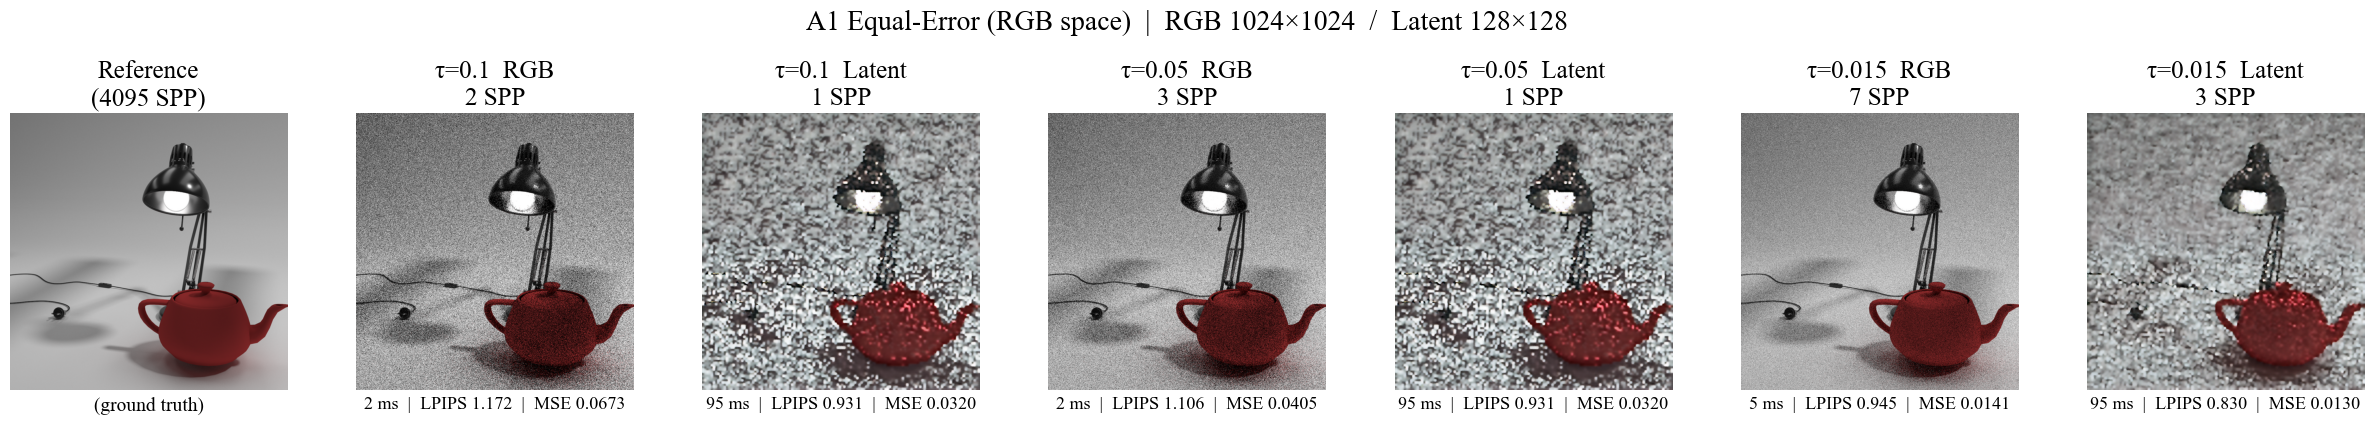

In [16]:
# ── Image grid: A1 results per threshold ─────────────────────────────────────
DISP = 512

def to_display(t):
    img = (t[0] if t.ndim == 4 else t).permute(1, 2, 0)[..., :3]
    img = img.clamp(0, 1).numpy()
    if max(img.shape[:2]) > DISP:
        from PIL import Image as PILImage
        img = np.array(PILImage.fromarray((img * 255).astype(np.uint8)).resize(
            (DISP, DISP), PILImage.LANCZOS)) / 255.0
    return img

fonts.apply(**{
    'axes.titlesize': 18, 'font.size': 18,
})

thresholds_sorted = sorted(results_a1.keys(), reverse=True)
n_cols = 1 + 2 * len(thresholds_sorted)  # ref + (RGB, Latent) per threshold

fig, axes = plt.subplots(1, n_cols, figsize=(3.5 * n_cols, 4.0))

# Converged reference
ax = axes[0]
ax.imshow(to_display(ref_rgb))
ax.set_title(f'Reference\n({REF_SPP} SPP)', fontsize=18)
ax.set_xlabel('(ground truth)', fontsize=14)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)

print('A1 image-grid metrics (raw MSE, images in [0,1]):')
col = 1
for tau in thresholds_sorted:
    r = results_a1[tau]
    for label, side, time_key in [('RGB', 'rgb', 'time_ms'), ('Latent', 'lat', 'total_ms')]:
        ax = axes[col]
        tensor = r[side]['image']
        ax.imshow(to_display(tensor))
        ax.set_title(f'τ={tau}  {label}\n{r[side]["spp"]} SPP', fontsize=18)
        t_ms = r[side][time_key]
        m, _ = compute_image_metrics(ref_rgb, tensor)
        ax.set_xlabel(
            f'{t_ms:.0f} ms  |  LPIPS {m["lpips"]:.3f}  |  MSE {m["mse"]:.4f}',
            fontsize=13,
        )
        print(f'  τ={tau} {label:6s}: {t_ms:.0f} ms  LPIPS={m["lpips"]:.4f}  MSE={m["mse"]:.6f}')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_visible(False)
        col += 1

plt.suptitle(
    f'A1 Equal-Error (RGB space)  |  RGB {RGB_RES}×{RGB_RES}  /  Latent {latent_res}×{latent_res}',
    fontsize=20, y=1.02,
)
plt.tight_layout()
plt.savefig('notebooks/equal_comparison_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Summary ───────────────────────────────────────────────────────────────────
# All MSE values are RAW (not ×100).
# A1/A3a MSE: pixel-space over images in [0,1].
# A2/A3b MSE: scaled VAE latent space (values NOT in [0,1]; ~0.26 floor is normal).

print('A1 Equal-Error (RGB space):')
for tau, r in sorted(results_a1.items(), reverse=True):
    speedup = r['rgb']['time_ms'] / r['lat']['total_ms']
    print(f'  τ={tau:<6}  RGB: {r["rgb"]["spp"]:5d} SPP  {r["rgb"]["time_ms"]:6.1f} ms'
          f'  |  Latent: {r["lat"]["spp"]:5d} SPP  {r["lat"]["total_ms"]:6.1f} ms'
          f'  ({speedup:.2f}× {"faster" if speedup > 1 else "slower"})')

print()
print('A2 Equal-Error (Latent space):')
for tau, r in sorted(results_a2.items(), reverse=True):
    speedup = r['rgb']['total_ms'] / r['lat']['total_ms']
    print(f'  τ={tau:<6}  RGB: {r["rgb"]["spp"]:5d} SPP  {r["rgb"]["total_ms"]:6.1f} ms'
          f'  |  Latent: {r["lat"]["spp"]:5d} SPP  {r["lat"]["total_ms"]:6.1f} ms'
          f'  ({speedup:.2f}×)')

print()
print('A3 Equal-Time (RGB space, raw MSE in [0,1]):')
for T, r in sorted(results_a3.items()):
    rs = r['rgb_space']['rgb'];  ls = r['rgb_space']['lat']
    rm = rs['metrics'];  lm = ls['metrics']
    rm_s = f'{rm["mse"]:.5f}' if rm else 'N/A'
    lm_s = f'{lm["mse"]:.5f}' if lm else 'N/A'
    print(f'  T={T:6} ms  RGB: {rs["spp"]:5d} SPP  MSE={rm_s}'
          f'  |  Latent: {ls["spp"]:5d} SPP  MSE={lm_s}')

print()
print('A3 Equal-Time (Latent space, raw MSE over scaled VAE latent):')
for T, r in sorted(results_a3.items()):
    rb = r['lat_space']['rgb'];  lb = r['lat_space']['lat']
    rm_s = f'{rb["mse"]:.5f}' if rb['mse'] is not None else 'N/A'
    lm_s = f'{lb["mse"]:.5f}' if lb['mse'] is not None else 'N/A'
    print(f'  T={T:6} ms  RGB: {rb["spp"]:5d} SPP  MSE={rm_s}'
          f'  |  Latent: {lb["spp"]:5d} SPP  MSE={lm_s}')

A1 Equal-Error (RGB space):
  τ=0.1     RGB:     2 SPP     1.6 ms  |  Latent:     1 SPP    94.6 ms  (0.02× slower)
  τ=0.05    RGB:     3 SPP     2.3 ms  |  Latent:     1 SPP    94.5 ms  (0.02× slower)
  τ=0.015   RGB:     7 SPP     5.1 ms  |  Latent:     3 SPP    94.7 ms  (0.05× slower)

A2 Equal-Error (Latent space):
  τ=0.5     RGB:     9 SPP    58.4 ms  |  Latent:     1 SPP     1.4 ms  (43.17×)
  τ=0.4     RGB:    16 SPP    63.1 ms  |  Latent:     2 SPP     1.4 ms  (45.64×)
  τ=0.3     RGB:    33 SPP    74.7 ms  |  Latent:     3 SPP     1.5 ms  (50.17×)

A3 Equal-Time (RGB space, raw MSE in [0,1]):

A3 Equal-Time (Latent space, raw MSE over scaled VAE latent):


## Super-Resolution Sweep

Runs the full latent pipeline at multiple resolutions (64×64 → 512×512, 128×128 → 1024×1024, 256×256 → 2048×2048) at a fixed equal SPP, and compares total latent pipeline time vs. RGB render time at each resolution.

**Note:** this sweep resets and re-initialises the renderer at each resolution, so it must run *after* the equal-error/equal-time analyses above.

In [18]:
# ── Release the equal-error experiment before the SR sweep ───────────────────
# The A1/A2 half leaves most of the GPU pinned and `empty_cache()` cannot get it
# back: the bulk of it sits in the CUDA-graph private pools of the compiled fp16
# decoder/encoder, which only a dynamo reset releases (it calls
# `reset_cudagraph_trees()`), and drjit's allocator holds device memory PyTorch
# cannot see or free.  Without this the 2048×2048 decode OOMs.


def gpu_free_gib():
    free_b, total_b = torch.cuda.mem_get_info()
    return free_b / 2**30, total_b / 2**30


def free_gpu():
    """Drop compiled artifacts, their CUDA-graph pools, and cached blocks."""
    torch._dynamo.reset()       # also calls torch._inductor reset_cudagraph_trees()
    gc.collect()
    torch.cuda.empty_cache()
    dr.flush_malloc_cache()     # drjit's pool is invisible to torch


_free_before, _total = gpu_free_gib()

mi_vae.vae.to('cpu')
free_gpu()

_free_after, _ = gpu_free_gib()
print(f'GPU free: {_free_before:.1f} → {_free_after:.1f} GiB  (of {_total:.1f} GiB)')
print('Note: the compiled decoder/encoder were dropped; re-running the '
      'equal-error analyses just recompiles them (reference + AOVs are kept).')


GPU free: 5.9 → 22.0 GiB  (of 23.5 GiB)
Note: the compiled decoder/encoder were dropped; re-running the equal-error analyses just recompiles them (reference + AOVs are kept).


In [19]:

from training.train_manager import TrainingManager

# ── Super-resolution sweep configuration ─────────────────────────────────────
SR_TILED_DECODE = False
SR_GT_SPP       = 255 if SR_TILED_DECODE else 256

def _max_ref_spp(rgb_res: int) -> int:
    n = 32 - 2 * int(round(np.log2(rgb_res)))
    return 2**n - 1

SR_RESOLUTIONS = [64, 128, 256, 512] if SR_TILED_DECODE else [64, 128, 256]
print(f'SR sweep: resolutions={SR_RESOLUTIONS}, GT_SPP={SR_GT_SPP}, TILED_DECODE={SR_TILED_DECODE}')


@torch.no_grad()
def run_at_latent_res(lat_res: int, gt_spp: int = 64, ref_spp: int = 1024) -> dict:
    """Run the full latent pipeline at lat_res; collect images + per-stage timings."""
    rgb_out_res = lat_res * mi_vae.vae_scale_factor
    _max_spp = (2**32 - 1) // (rgb_out_res * rgb_out_res)
    gt_spp = min(gt_spp, _max_spp)

    renderers.rgb    = None
    renderers.latent = None
    renderers.aov    = None
    # Each resolution compiles its own max-autotune decoder; without dropping the
    # previous one's CUDA-graph pool, the 2048×2048 compile OOMs.
    free_gpu()

    renderers.latent_res = lat_res
    renderers.rgb_res    = rgb_out_res
    renderers.aov_res    = lat_res
    renderers.reset_renderers()
    renderers.load_scene_checkpoint(SCENE_CKPT)
    renderers.set_optimizable_parameters(TrainingManager.SCENE_OPTIMIZATION_TARGETS)
    nets.load_checkpoint(REFINER_CKPT)
    nets.eval()

    _opt = renderers.get_scaled_opt_params()

    mi_vae.vae.to('cpu');  torch.cuda.empty_cache()

    # ── latent render ────────────────────────────────────────────────────────
    renderers.latent.set_spp(gt_spp)
    with dr.suspend_grad():
        latent_raw_gpu, _ = renderers.latent.render(seed=0, opt_params=_opt)
        latent_raw = latent_raw_gpu.float().cpu()
        del latent_raw_gpu
    latent_time_ms = DrTimer(lambda: renderers.latent.render(seed=0, opt_params=_opt), warmup=0).timeit(1)
    torch.cuda.empty_cache()

    # ── AOVs ─────────────────────────────────────────────────────────────────
    with dr.suspend_grad():
        aovs_gpu = renderers.aov.render(renderers.rgb.scene, renderers.latent.params, seed=0)

    # ── refine ───────────────────────────────────────────────────────────────
    torch.cuda.empty_cache()
    _lat_gpu = latent_raw.to(device)
    latent_ref_gpu, _ = nets.refine_latent_conv(_lat_gpu, aovs_gpu)
    latent_ref = latent_ref_gpu.float().cpu()
    del latent_ref_gpu
    refine_time_ms = bench.Timer(
        stmt='nets.refine_latent_conv(lat, aovs)',
        globals={'nets': nets, 'lat': _lat_gpu, 'aovs': aovs_gpu},
    ).timeit(1).mean * 1e3
    del aovs_gpu, _lat_gpu;  torch.cuda.empty_cache()

    # ── comparison RGB render ─────────────────────────────────────────────────
    rgb = None;  rgb_time_ms = None
    try:
        renderers.rgb.set_spp(gt_spp)
        with dr.suspend_grad():
            rgb_gpu = renderers.rgb.render(seed=0, denoiser=False)
            rgb = rgb_gpu.float().cpu();  del rgb_gpu
        rgb_time_ms = DrTimer(
            lambda: renderers.rgb.render(seed=0, denoiser=False), warmup=0
        ).timeit(1)
        torch.cuda.empty_cache()
    except torch.cuda.OutOfMemoryError as e:
        print(f"  RGB ({gt_spp} SPP) OOM at {rgb_out_res}×{rgb_out_res}: {e}")

    # ── converged reference ──────────────────────────────────────────────────
    ref = None
    try:
        renderers.rgb.set_spp(ref_spp)
        with dr.suspend_grad():
            ref_gpu = renderers.rgb.render(seed=0, denoiser=False)
            ref = ref_gpu.float().cpu();  del ref_gpu
        torch.cuda.empty_cache()
    except torch.cuda.OutOfMemoryError as e:
        print(f"  Ref ({ref_spp} SPP) OOM at {rgb_out_res}×{rgb_out_res}: {e}")

    # ── decode ───────────────────────────────────────────────────────────────
    mi_vae.vae.to(device);  torch.cuda.empty_cache()

    _vae_decode = mi_vae.vae.decode

    @torch.compile(dynamic=False, fullgraph=True, mode='max-autotune')
    def _compiled_decode(z):
        return _vae_decode(z).sample

    def _decode(latents):
        latents = latents / mi_vae.scaling_factor
        if mi_vae.shift_factor is not None:
            latents = latents + mi_vae.shift_factor
        latents = latents.to(dtype=mi_vae.vae.dtype, device=mi_vae.vae.device)
        image = _compiled_decode(latents)
        return mi_vae.image_processor.postprocess(image, output_type='pt')

    mi_vae.decode = _decode

    _ = mi_vae.decode(latent_raw);  del _;  torch.cuda.empty_cache()

    decoded_raw = mi_vae.decode(latent_raw).float().cpu()
    decode_time_ms = bench.Timer(
        stmt='mi_vae.decode(lat).float().cpu()',
        globals={'mi_vae': mi_vae, 'lat': latent_raw},
    ).timeit(1).mean * 1e3
    torch.cuda.empty_cache()

    decoded_ref = mi_vae.decode(latent_ref).float().cpu()
    torch.cuda.empty_cache()

    return {
        'latent_res': lat_res, 'rgb_res': rgb_out_res,
        'latent_raw': latent_raw, 'latent_ref': latent_ref,
        'decoded_raw': decoded_raw, 'decoded_ref': decoded_ref,
        'rgb': rgb, 'ref': ref,
        'latent_time_ms': latent_time_ms, 'refine_time_ms': refine_time_ms,
        'decode_time_ms': decode_time_ms, 'rgb_time_ms': rgb_time_ms,
        'gt_spp': gt_spp, 'ref_spp': ref_spp,
    }


print('run_at_latent_res defined.')

SR sweep: resolutions=[64, 128, 256], GT_SPP=256, TILED_DECODE=False
run_at_latent_res defined.


In [20]:
sr_results = {}
for r in SR_RESOLUTIONS:
    rgb_r     = r * mi_vae.vae_scale_factor
    ref_spp_r = _max_ref_spp(rgb_r)
    print(f"\n--- Latent {r}×{r}  →  RGB {rgb_r}×{rgb_r}  (ref SPP: {ref_spp_r}) ---")
    try:
        sr_results[r] = run_at_latent_res(r, gt_spp=SR_GT_SPP, ref_spp=ref_spp_r)
        res = sr_results[r]
        print(f"  decoded_raw : {res['decoded_raw'].shape}")
        print(f"  decoded_ref : {res['decoded_ref'].shape}")
        print(f"  rgb ({SR_GT_SPP:5d} spp): {res['rgb'].shape if res['rgb'] is not None else 'OOM'}")
        print(f"  ref ({ref_spp_r:5d} spp): {res['ref'].shape if res['ref'] is not None else 'OOM'}")
    except torch.cuda.OutOfMemoryError as e:
        print(f"  Entire run OOM: {e}")
        sr_results[r] = None

print("\nSR sweep done.")


--- Latent 64×64  →  RGB 512×512  (ref SPP: 16383) ---


/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/drjit/ast.py:838: RuntimeWarning: The AST-transforming decorator @drjit.syntax was called more than 1000 times by your program. Since transforming and recompiling Python code is a relatively expensive operation, it should not be used within loops or subroutines. Please move the function to be transformed to the top program level and decorate it there.
  warnings.warn(


Need 3 custom emitters.
Need 18 custom BSDFs.
Need 13 SPDs for this scene.
  decoded_raw : torch.Size([1, 3, 512, 512])
  decoded_ref : torch.Size([1, 3, 512, 512])
  rgb (  256 spp): torch.Size([1, 3, 512, 512])
  ref (16383 spp): torch.Size([1, 3, 512, 512])

--- Latent 128×128  →  RGB 1024×1024  (ref SPP: 4095) ---


/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/drjit/ast.py:838: RuntimeWarning: The AST-transforming decorator @drjit.syntax was called more than 1000 times by your program. Since transforming and recompiling Python code is a relatively expensive operation, it should not be used within loops or subroutines. Please move the function to be transformed to the top program level and decorate it there.
  warnings.warn(


Need 3 custom emitters.
Need 18 custom BSDFs.
Need 13 SPDs for this scene.
  decoded_raw : torch.Size([1, 3, 1024, 1024])
  decoded_ref : torch.Size([1, 3, 1024, 1024])
  rgb (  256 spp): torch.Size([1, 3, 1024, 1024])
  ref ( 4095 spp): torch.Size([1, 3, 1024, 1024])

--- Latent 256×256  →  RGB 2048×2048  (ref SPP: 1023) ---


/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/drjit/ast.py:838: RuntimeWarning: The AST-transforming decorator @drjit.syntax was called more than 1000 times by your program. Since transforming and recompiling Python code is a relatively expensive operation, it should not be used within loops or subroutines. Please move the function to be transformed to the top program level and decorate it there.
  warnings.warn(


Need 3 custom emitters.
Need 18 custom BSDFs.
Need 13 SPDs for this scene.
  decoded_raw : torch.Size([1, 3, 2048, 2048])
  decoded_ref : torch.Size([1, 3, 2048, 2048])
  rgb (  256 spp): torch.Size([1, 3, 2048, 2048])
  ref ( 1023 spp): torch.Size([1, 3, 2048, 2048])

SR sweep done.


Super-resolution equal-SPP timing:
  64×64→512×512  Latent: 5+0+23=28 ms  |  RGB: 44 ms
  128×128→1024×1024  Latent: 17+1+94=112 ms  |  RGB: 175 ms
  256×256→2048×2048  Latent: 68+5+444=517 ms  |  RGB: 703 ms



NameError: name 'BAR_PAD' is not defined

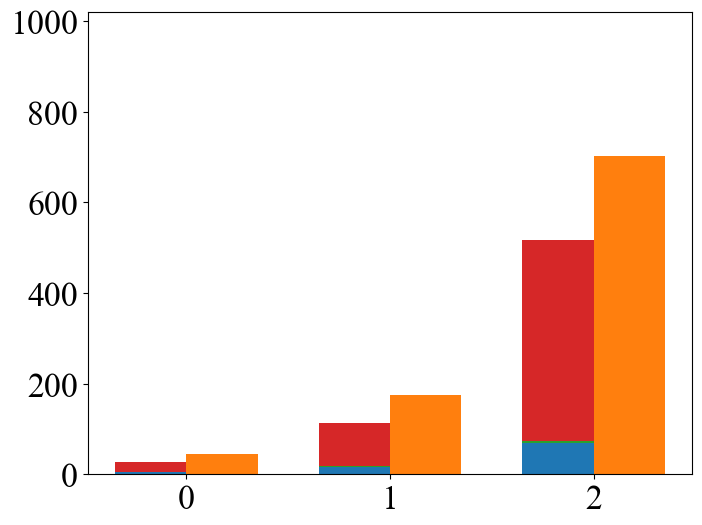

In [24]:
# ── SR timing bar chart ───────────────────────────────────────────────────────
# Style, colours, PANEL_W/H, F and LEGEND come from the A1/A2 cell above.
SR_TITLE = f'Equal SPP ({SR_GT_SPP} SPP each)'


def draw_sr(ax):
    """Equal-SPP super-resolution timing: latent pipeline vs. RGB render."""
    valid  = [(r, sr_results[r]) for r in SR_RESOLUTIONS if sr_results.get(r) is not None]
    labels = [f"{r}×{r}\n→ {res['rgb_res']}×{res['rgb_res']}" for r, res in valid]
    lat_t  = [res['latent_time_ms'] for _, res in valid]
    ref_t  = [res['refine_time_ms'] for _, res in valid]
    dec_t  = [res['decode_time_ms'] for _, res in valid]
    rgb_t  = [res['rgb_time_ms'] if res['rgb_time_ms'] is not None else 0 for _, res in valid]
    tot_t  = [l + r + d for l, r, d in zip(lat_t, ref_t, dec_t)]
    x = np.arange(len(labels))

    ax.bar(x - WIDTH/2, lat_t, WIDTH, color=C_LAT_RENDER)
    ax.bar(x - WIDTH/2, ref_t, WIDTH, color=C_REFINE, bottom=lat_t)
    ax.bar(x - WIDTH/2, dec_t, WIDTH, color=C_DECODE,
           bottom=[l + r for l, r in zip(lat_t, ref_t)])
    bars_rgb = ax.bar(x + WIDTH/2, rgb_t, WIDTH, color=C_RGB_RENDER)

    ax.set_ylim(0, max(tot_t + rgb_t) * 1.45)
    # Same pair-edge anchoring as the equal-error panels: the latent label ends
    # at the shared edge, the RGB label starts there.
    for xi, tot in zip(x, tot_t):
        ax.text(xi - BAR_PAD, tot * 1.005, f'{tot:.0f} ms',
                ha='right', va='bottom', fontsize=FS_BAR)
    for xi, h in zip(x, rgb_t):
        if h > 0:
            ax.text(xi + BAR_PAD, h * 1.005, f'{h:.0f} ms',
                    ha='left', va='bottom', fontsize=FS_BAR)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, ha='center')
    # Resolutions are split between tick labels and the axis label: at equal
    # panel width the full 'Latent 128×128 → 1024×1024 RGB' does not fit.  The
    # ticks also run a size below the other panels' or they collide.
    ax.tick_params(axis='x', labelsize=FS_SR_TICK)
    ax.set_xlabel('Latent → RGB Resolution', fontweight='bold')
    ax.xaxis.set_label_coords(0.5, XLABEL_Y)   # same height as the other panels
    ax.set_ylabel('Time (ms)', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)


_valid = [(r, sr_results[r]) for r in SR_RESOLUTIONS if sr_results.get(r) is not None]

print('Super-resolution equal-SPP timing:')
for r, res in _valid:
    _tot = res['latent_time_ms'] + res['refine_time_ms'] + res['decode_time_ms']
    _rgb = res['rgb_time_ms'] if res['rgb_time_ms'] is not None else 0
    print(f'  {r}×{r}→{res["rgb_res"]}×{res["rgb_res"]}  '
          f'Latent: {res["latent_time_ms"]:.0f}+{res["refine_time_ms"]:.0f}'
          f'+{res["decode_time_ms"]:.0f}={_tot:.0f} ms  |  RGB: {_rgb:.0f} ms')
print()

# ── Standalone SR figure ──────────────────────────────────────────────────────
# Standalone keeps the y-label the combined panel drops, so add its width back:
# that keeps the plot box itself the same size as in the combined figure.
fig, ax = plt.subplots(figsize=(PANEL_W + 0.8, PANEL_H))
draw_sr(ax)
ax.set_title(SR_TITLE, fontsize=20 * F, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/superresolution_timing.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Combined figure: equal-error (A1, A2) + super-resolution timing, one row ──
# Same three panels as above, same width each, sharing one legend.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(3 * PANEL_W, PANEL_H))
draw_a1(ax1)
draw_a2(ax2)
draw_sr(ax3)
ax3.set_ylabel('')   # same unit as the left panel — label it once for the figure

_legend = fig.legend(handles=LEGEND, loc='lower center', ncol=5,
                     bbox_to_anchor=(0.5, 0.0), fontsize=18 * F, frameon=True)
plt.tight_layout(rect=[0, 0.10, 1, 0.90], pad=0.5)

# tight_layout equalises *columns*, not plot boxes: the two y-labelled panels
# end up narrower than the middle one, so trim all three to the smallest.
_w = min(a.get_position().width for a in (ax1, ax2, ax3))
for a in (ax1, ax2, ax3):
    _p = a.get_position()
    a.set_position([_p.x0, _p.y0, _w, _p.height])

# Nudge the SR panel right: the divider needs whitespace either side of it, and
# the wider gap also reads as the equal-error pair being one group.
_p = ax3.get_position()
ax3.set_position([_p.x0 + 0.022, _p.y0, _p.width, _p.height])

# Reclaim the dead band above the legend, giving it to the plot bodies.
fit_axes_above_legend(fig, (ax1, ax2, ax3), _legend)

# All four titles share one row, flush with the axes tops.
title_y = ax1.get_position().y1 + 0.02
label_equal_error(fig, ax1, ax2, title_y)
_p3 = ax3.get_position()
fig.text((_p3.x0 + _p3.x1) / 2, title_y, SR_TITLE,
         ha='center', va='bottom', fontsize=22 * F, fontweight='bold')

# Divider in the real gap between the panels — tight bboxes include the y-label,
# axes positions do not, and placing it by the latter would cut ax3's off.
fig.canvas.draw()
_inv = fig.transFigure.inverted()
_b1 = _inv.transform_bbox(ax1.get_tightbbox(fig.canvas.get_renderer()))
_b2 = _inv.transform_bbox(ax2.get_tightbbox(fig.canvas.get_renderer()))
_b3 = _inv.transform_bbox(ax3.get_tightbbox(fig.canvas.get_renderer()))
_sep_x = (_b2.x1 + _b3.x0) / 2
fig.add_artist(Line2D([_sep_x, _sep_x], [0.13, title_y + 0.06],
                      color='0.6', lw=3, alpha=0.65, linestyle=(0, (1, 2.2)),
                      transform=fig.transFigure))

# Centre the legend on the panels themselves: savefig trims unequal margins, so
# anchoring at figure-centre 0.5 lands visibly off-centre in the saved file.
_legend.set_bbox_to_anchor(((_b1.x0 + _b3.x1) / 2, 0.0), transform=fig.transFigure)

plt.savefig('notebooks/combined_figure.png', dpi=150, bbox_inches='tight')
# fonts.savefig outlines the PDF's text, which the camera-ready font check requires.
fonts.savefig(fig, 'notebooks/combined_figure.pdf', bbox_inches='tight')
plt.show()
print('Saved: notebooks/combined_figure.png and .pdf')
